# SARIMAX Expanding-Window Baseline (2014-2025)

This notebook implements a simple SARIMAX baseline with the same expanding-window split philosophy used in the DL pipeline:

- Train on `2013..(Y-1)` and test on `Y`
- Test years `2014..2025` (12 folds)
- Rolling yearly prediction with `prediction_length=24` and `stride=24`
- One fixed model spec for all folds:
  - `order=(1,1,1)`
  - `seasonal_order=(1,1,1,24)`
- Exogenous variables: all non-target columns **except leakage columns**
  - Excluded by default: `consumption_gasnet`, `consumption_jmpnet`, `consumption_smpnet`, `consumption_vcpnet`

Outputs:

- Per-fold predictions CSVs
- Fold summary metrics CSV
- Plots and sanity checks

In [ ]:
from __future__ import annotations

import json
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


@dataclass(frozen=True)
class NotebookConfig:
    split_variant: str = "base"
    target_col: str = "consumption_total"
    order: tuple[int, int, int] = (1, 1, 1)
    seasonal_order: tuple[int, int, int, int] = (1, 1, 1, 24)
    prediction_length: int = 24
    stride: int = 24
    # Lowered to keep full 12-fold runtime practical with high-dimensional exog.
    maxiter: int = 30
    # Prevent leakage by default.
    exclude_leaky_consumption_exog: bool = True
    leaky_consumption_columns: tuple[str, ...] = (
        "consumption_gasnet",
        "consumption_jmpnet",
        "consumption_smpnet",
        "consumption_vcpnet",
    )
    # Keep None for full 12 folds. Set an int for quick debugging.
    max_folds_to_run: int | None = None


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root with pyproject.toml")


CONFIG = NotebookConfig()
PROJECT_ROOT = find_project_root(Path.cwd()) / "result"
SPLIT_ROOT = PROJECT_ROOT / "data" / "preprocessed" / "splits" / CONFIG.split_variant
TRAIN_SPLITS_DIR = SPLIT_ROOT / "ranges_from_2013_to_2025"
TEST_SPLITS_DIR = SPLIT_ROOT / "single_years"
RUN_PARAMS_PATH = SPLIT_ROOT / "run_params.json"

OUTPUT_ROOT = PROJECT_ROOT / "results" / "sarimax"
PREDICTIONS_DIR = OUTPUT_ROOT / "predictions_by_year"
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Split root:   {SPLIT_ROOT}")
print(f"Output root:  {OUTPUT_ROOT}")
print(f"Model order:  order={CONFIG.order}, seasonal_order={CONFIG.seasonal_order}")
print(
    f"Rolling cfg:  prediction_length={CONFIG.prediction_length}, stride={CONFIG.stride}"
)
print(f"Exclude leaky consumption exog: {CONFIG.exclude_leaky_consumption_exog}")

Project root: /local_storage/users/sli0124/diplomovy-projekt
Split root:   /local_storage/users/sli0124/diplomovy-projekt/data/preprocessed/splits/base
Output root:  /local_storage/users/sli0124/diplomovy-projekt/results/sarimax
Model order:  order=(1, 1, 1), seasonal_order=(1, 1, 1, 24)
Rolling cfg:  prediction_length=24, stride=24
Exclude leaky consumption exog: True


In [10]:
def to_datetime_index(df: pd.DataFrame) -> pd.DatetimeIndex:
    timestamp = pd.to_datetime(df[["year", "month", "day", "hour"]], errors="coerce")
    if timestamp.isna().any():
        raise ValueError("Found invalid datetime values while constructing index")
    return pd.DatetimeIndex(timestamp)


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if not np.any(mask):
        return float("nan")
    return float(
        100.0 * np.mean(2.0 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask])
    )


def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    mask = y_true != 0
    if not np.any(mask):
        return float("nan")
    return float(100.0 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": mape(y_true, y_pred),
        "smape": smape(y_true, y_pred),
        "r2": float(r2_score(y_true, y_pred)),
    }


def parse_year_from_name(file_name: str, prefix: str) -> int:
    # Example: range_2013_2024.csv with prefix="range_2013_"
    return int(file_name.replace(prefix, "").replace(".csv", ""))

In [11]:
with RUN_PARAMS_PATH.open("r", encoding="utf-8") as f:
    run_params = json.load(f)

train_files = sorted(p.name for p in TRAIN_SPLITS_DIR.glob("range_2013_*.csv"))
test_files = sorted(p.name for p in TEST_SPLITS_DIR.glob("year_*.csv"))

available_train_end_years = {
    parse_year_from_name(name, "range_2013_") for name in train_files
}
available_test_years = {
    int(name.replace("year_", "").replace(".csv", "")) for name in test_files
}

folds: list[dict[str, int | Path]] = []
for test_year in sorted(y for y in available_test_years if y >= 2014):
    train_end_year = test_year - 1
    if train_end_year in available_train_end_years:
        folds.append(
            {
                "test_year": test_year,
                "train_end_year": train_end_year,
                "train_path": TRAIN_SPLITS_DIR / f"range_2013_{train_end_year}.csv",
                "test_path": TEST_SPLITS_DIR / f"year_{test_year}.csv",
            }
        )

if CONFIG.max_folds_to_run is not None:
    folds = folds[: CONFIG.max_folds_to_run]

print("Run params schema:", run_params.get("schema"))
print("Anchor year:", run_params.get("splits", {}).get("range_anchor_year"))
print("Holdout last year:", run_params.get("splits", {}).get("holdout_last_year"))
print("Folds discovered:", len(folds))
print("Test years:", [int(f["test_year"]) for f in folds])

assert len(folds) > 0, "No folds discovered"
if CONFIG.max_folds_to_run is None:
    assert len(folds) == 12, f"Expected 12 folds (2014..2025), got {len(folds)}"

Run params schema: preprocessing.run_params.v1
Anchor year: 2013
Holdout last year: True
Folds discovered: 12
Test years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [ ]:
def load_fold_frame(path: Path, target_col: str) -> tuple[pd.Series, pd.DataFrame]:
    df = pd.read_csv(path)
    df.index = to_datetime_index(df)
    df = df.sort_index()

    if target_col not in df.columns:
        raise KeyError(f"Missing target column '{target_col}' in {path}")

    y = df[target_col].astype(float)
    x = df.drop(columns=[target_col]).astype(float)

    if y.isna().any():
        raise ValueError(f"Target contains NaN values in {path}")
    if x.isna().any().any():
        raise ValueError(f"Exogenous features contain NaN values in {path}")

    if not y.index.is_monotonic_increasing:
        raise ValueError(f"Datetime index is not sorted in {path}")

    return y, x


def scale_exog_by_train(
    x_train: pd.DataFrame,
    x_test: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    # Statsmodels can become numerically unstable with mixed-scale exog.
    # Standardize exogenous features using train statistics only.
    mu = x_train.mean(axis=0)
    sigma = x_train.std(axis=0).replace(0.0, 1.0)

    x_train_scaled = (x_train - mu) / sigma
    x_test_scaled = (x_test - mu) / sigma

    train_arr = x_train_scaled.to_numpy(dtype=float)
    test_arr = x_test_scaled.to_numpy(dtype=float)
    if not np.isfinite(train_arr).all() or not np.isfinite(test_arr).all():
        raise ValueError("Scaled exogenous features contain non-finite values")

    return x_train_scaled, x_test_scaled


def fit_sarimax(y_train: pd.Series, x_train: pd.DataFrame) -> object:
    model = SARIMAX(
        endog=y_train,
        exog=x_train,
        order=CONFIG.order,
        seasonal_order=CONFIG.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False, maxiter=CONFIG.maxiter)


def rolling_forecast(
    fitted_model: object,
    y_test: pd.Series,
    x_test: pd.DataFrame,
    prediction_length: int,
    stride: int,
) -> pd.DataFrame:
    n_test = len(y_test)
    state = fitted_model
    observed_until = -1

    rows: list[dict[str, object]] = []
    unstable_window_count = 0

    for origin in range(0, n_test, stride):
        if origin > observed_until + 1:
            start = observed_until + 1
            end = origin
            state = state.append(
                endog=y_test.iloc[start:end],
                exog=x_test.iloc[start:end],
                refit=False,
            )
            observed_until = end - 1

        steps = min(prediction_length, n_test - origin)
        exog_future = x_test.iloc[origin : origin + steps]
        y_true = y_test.iloc[origin : origin + steps]

        forecast = state.get_forecast(
            steps=steps, exog=exog_future
        ).predicted_mean.to_numpy(dtype=float)
        finite_mask = np.isfinite(forecast)
        has_large_values = (
            finite_mask.any() and np.max(np.abs(forecast[finite_mask])) > 1e8
        )

        # Guardrail: replace non-finite or absurdly large values with a naive fallback.
        if (not finite_mask.all()) or has_large_values:
            unstable_window_count += 1
            fallback_value = float(state.data.endog[-1])
            forecast = np.where(finite_mask, forecast, fallback_value)
            forecast = np.clip(forecast, -1e8, 1e8)

        for ts, yt, yp in zip(y_true.index, y_true.to_numpy(), forecast):
            rows.append(
                {
                    "timestamp": ts,
                    "origin_timestamp": y_test.index[origin],
                    "y_true": float(yt),
                    "y_pred": float(yp),
                }
            )

    predictions = pd.DataFrame(rows)
    if predictions.empty:
        raise ValueError("Rolling forecast produced no predictions")

    predictions = predictions.sort_values("timestamp").reset_index(drop=True)

    if unstable_window_count > 0:
        print(
            f"   warning: stabilized {unstable_window_count} unstable forecast windows"
        )

    return predictions

In [14]:
all_fold_metrics: list[dict[str, object]] = []
all_fold_predictions: list[pd.DataFrame] = []

for i, fold in enumerate(folds, start=1):
    test_year = int(fold["test_year"])
    train_end_year = int(fold["train_end_year"])
    train_path = Path(fold["train_path"])
    test_path = Path(fold["test_path"])

    print(
        f"[{i}/{len(folds)}] Fold test_year={test_year}: train=2013..{train_end_year}"
    )

    y_train, x_train = load_fold_frame(train_path, CONFIG.target_col)
    y_test, x_test = load_fold_frame(test_path, CONFIG.target_col)

    if list(x_train.columns) != list(x_test.columns):
        raise ValueError(
            f"Train/test exogenous columns mismatch for test year {test_year}"
        )

    # Diagnostic + guard against leakage from components that sum to target.
    leaky_cols_present = [
        c for c in CONFIG.leaky_consumption_columns if c in x_train.columns
    ]
    if i == 1 and leaky_cols_present:
        max_identity_residual = float(
            (y_train - x_train[leaky_cols_present].sum(axis=1)).abs().max()
        )
        print(
            "   diagnostic: max |consumption_total - sum(consumption components)| "
            f"on train={max_identity_residual:.6f}"
        )

    if CONFIG.exclude_leaky_consumption_exog and leaky_cols_present:
        x_train = x_train.drop(columns=leaky_cols_present)
        x_test = x_test.drop(columns=leaky_cols_present)
        print(f"   dropped leakage columns: {leaky_cols_present}")

    x_train_scaled, x_test_scaled = scale_exog_by_train(x_train, x_test)

    model_fit = fit_sarimax(y_train=y_train, x_train=x_train_scaled)
    fold_pred = rolling_forecast(
        fitted_model=model_fit,
        y_test=y_test,
        x_test=x_test_scaled,
        prediction_length=CONFIG.prediction_length,
        stride=CONFIG.stride,
    )

    y_true_np = fold_pred["y_true"].to_numpy(dtype=float)
    y_pred_np = fold_pred["y_pred"].to_numpy(dtype=float)

    finite_mask = np.isfinite(y_true_np) & np.isfinite(y_pred_np)
    if not finite_mask.all():
        removed = int((~finite_mask).sum())
        print(
            f"   warning: dropping {removed} non-finite prediction points before metrics"
        )
        y_true_np = y_true_np[finite_mask]
        y_pred_np = y_pred_np[finite_mask]

    if len(y_true_np) == 0:
        raise ValueError(f"No valid prediction points for metrics in fold {test_year}")

    fold_metrics = compute_metrics(y_true_np, y_pred_np)

    fold_metrics_row = {
        "test_year": test_year,
        "train_years": f"2013-{train_end_year}",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "n_predictions": int(len(fold_pred)),
        "n_exog": int(x_train.shape[1]),
        **fold_metrics,
    }
    all_fold_metrics.append(fold_metrics_row)

    fold_pred = fold_pred.assign(
        test_year=test_year,
        train_years=f"2013-{train_end_year}",
    )
    all_fold_predictions.append(fold_pred)

    pred_path = PREDICTIONS_DIR / f"sarimax_predictions_{test_year}.csv"
    fold_pred.to_csv(pred_path, index=False)

    print(
        "   "
        f"MAE={fold_metrics['mae']:.2f}, RMSE={fold_metrics['rmse']:.2f}, "
        f"MAPE={fold_metrics['mape']:.2f}%, SMAPE={fold_metrics['smape']:.2f}%, R2={fold_metrics['r2']:.4f}"
    )

metrics_df = (
    pd.DataFrame(all_fold_metrics).sort_values("test_year").reset_index(drop=True)
)
predictions_df = pd.concat(all_fold_predictions, ignore_index=True)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
metrics_path = OUTPUT_ROOT / "sarimax_fold_metrics.csv"
predictions_path = OUTPUT_ROOT / "sarimax_predictions_all_folds.csv"

metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(predictions_path, index=False)

print("\nSaved:")
print(f"- Metrics summary: {metrics_path}")
print(f"- All predictions: {predictions_path}")
print(f"- Per-year predictions dir: {PREDICTIONS_DIR}")

metrics_df

[1/12] Fold test_year=2014: train=2013..2013
   diagnostic: max |consumption_total - sum(consumption components)| on train=0.000000
   dropped leakage columns: ['consumption_gasnet', 'consumption_jmpnet', 'consumption_smpnet', 'consumption_vcpnet']
   MAE=45217.53, RMSE=81868.19, MAPE=6.58%, SMAPE=6.45%, R2=0.9430
[2/12] Fold test_year=2015: train=2013..2014
   dropped leakage columns: ['consumption_gasnet', 'consumption_jmpnet', 'consumption_smpnet', 'consumption_vcpnet']
   MAE=42850.53, RMSE=61979.07, MAPE=6.16%, SMAPE=6.09%, R2=0.9701
[3/12] Fold test_year=2016: train=2013..2015
   dropped leakage columns: ['consumption_gasnet', 'consumption_jmpnet', 'consumption_smpnet', 'consumption_vcpnet']
   MAE=51103.53, RMSE=89589.93, MAPE=7.33%, SMAPE=7.08%, R2=0.9469
[4/12] Fold test_year=2017: train=2013..2016
   dropped leakage columns: ['consumption_gasnet', 'consumption_jmpnet', 'consumption_smpnet', 'consumption_vcpnet']
   MAE=45983.26, RMSE=64995.32, MAPE=6.39%, SMAPE=6.33%, R2=0.97

,test_year,train_years,n_train,n_test,n_predictions,n_exog,mae,rmse,mape,smape,r2
0,2014,2013-2013,8760,8760,8760,24,45217.525461,81868.189778,6.577246,6.451688,0.942993
1,2015,2013-2014,17520,8760,8760,24,42850.532270,61979.065815,6.162335,6.089104,0.970075
2,2016,2013-2015,26280,8784,8784,24,51103.527225,89589.933531,7.332087,7.078213,0.946865
3,2017,2013-2016,35064,8760,8760,24,45983.260277,64995.319958,6.388050,6.325048,0.976048
4,2018,2013-2017,43824,8760,8760,24,42631.213327,61523.199262,6.348026,6.288839,0.979604
5,2019,2013-2018,52584,8760,8760,24,47108.068432,67884.059822,6.596012,6.541857,0.967410
6,2020,2013-2019,61344,8784,8784,24,44600.299195,63149.391219,6.137783,6.080190,0.971651
7,2021,2013-2020,70128,8760,8760,24,46362.212830,65568.192572,5.598198,5.564685,0.973551
8,2022,2013-2021,78888,8760,8760,24,38765.152503,55847.591642,5.949237,5.909584,0.975617
9,2023,2013-2022,87648,8760,8760,24,39132.202508,56276.199249,6.789378,6.731869,0.969657


In [15]:
display(metrics_df)

print("\nAverage across folds:")
display(
    metrics_df[["mae", "rmse", "mape", "smape", "r2"]]
    .mean()
    .rename("mean")
    .to_frame()
    .T
)

print("\nBest and worst folds by RMSE:")
display(metrics_df.nsmallest(3, "rmse"))
display(metrics_df.nlargest(3, "rmse"))

,test_year,train_years,n_train,n_test,n_predictions,n_exog,mae,rmse,mape,smape,r2
0,2014,2013-2013,8760,8760,8760,24,45217.525461,81868.189778,6.577246,6.451688,0.942993
1,2015,2013-2014,17520,8760,8760,24,42850.532270,61979.065815,6.162335,6.089104,0.970075
2,2016,2013-2015,26280,8784,8784,24,51103.527225,89589.933531,7.332087,7.078213,0.946865
3,2017,2013-2016,35064,8760,8760,24,45983.260277,64995.319958,6.388050,6.325048,0.976048
4,2018,2013-2017,43824,8760,8760,24,42631.213327,61523.199262,6.348026,6.288839,0.979604
5,2019,2013-2018,52584,8760,8760,24,47108.068432,67884.059822,6.596012,6.541857,0.967410
6,2020,2013-2019,61344,8784,8784,24,44600.299195,63149.391219,6.137783,6.080190,0.971651
7,2021,2013-2020,70128,8760,8760,24,46362.212830,65568.192572,5.598198,5.564685,0.973551
8,2022,2013-2021,78888,8760,8760,24,38765.152503,55847.591642,5.949237,5.909584,0.975617
9,2023,2013-2022,87648,8760,8760,24,39132.202508,56276.199249,6.789378,6.731869,0.969657



Average across folds:


,mae,rmse,mape,smape,r2
mean,43545.301617,65098.589794,6.417642,6.337783,0.968143



Best and worst folds by RMSE:


,test_year,train_years,n_train,n_test,n_predictions,n_exog,mae,rmse,mape,smape,r2
10,2024,2013-2023,96408,8784,8784,24,37845.885007,54671.058393,6.413380,6.347107,0.971645
8,2022,2013-2021,78888,8760,8760,24,38765.152503,55847.591642,5.949237,5.909584,0.975617
9,2023,2013-2022,87648,8760,8760,24,39132.202508,56276.199249,6.789378,6.731869,0.969657


,test_year,train_years,n_train,n_test,n_predictions,n_exog,mae,rmse,mape,smape,r2
2,2016,2013-2015,26280,8784,8784,24,51103.527225,89589.933531,7.332087,7.078213,0.946865
0,2014,2013-2013,8760,8760,8760,24,45217.525461,81868.189778,6.577246,6.451688,0.942993
5,2019,2013-2018,52584,8760,8760,24,47108.068432,67884.059822,6.596012,6.541857,0.967410


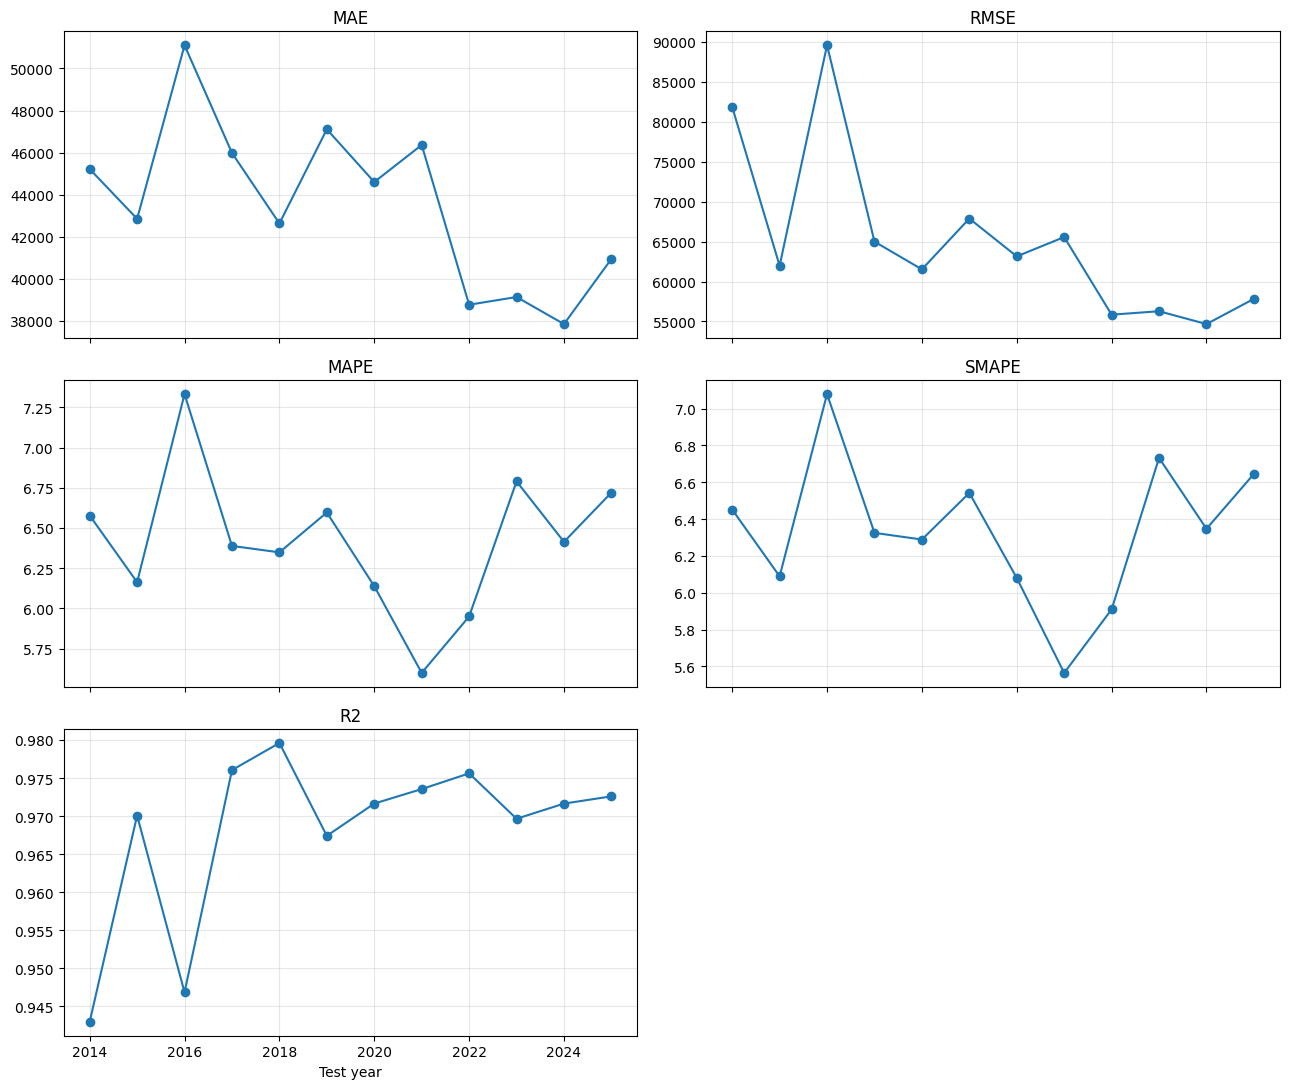

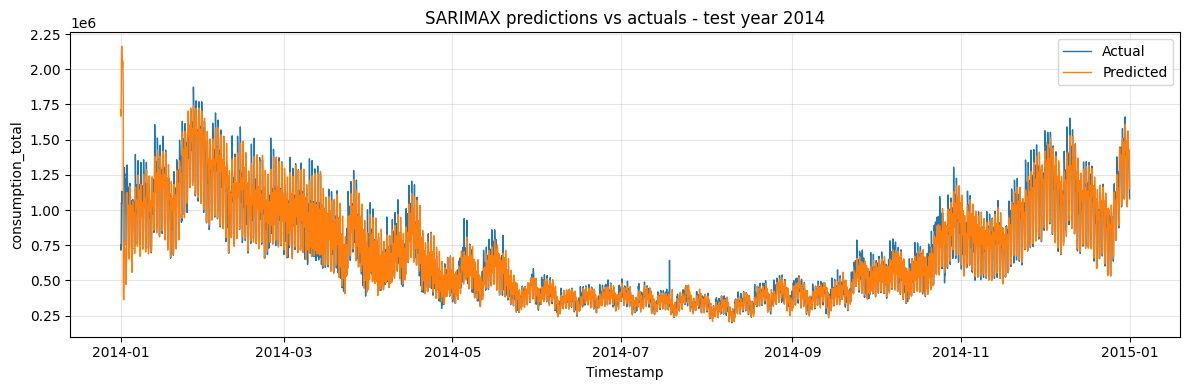

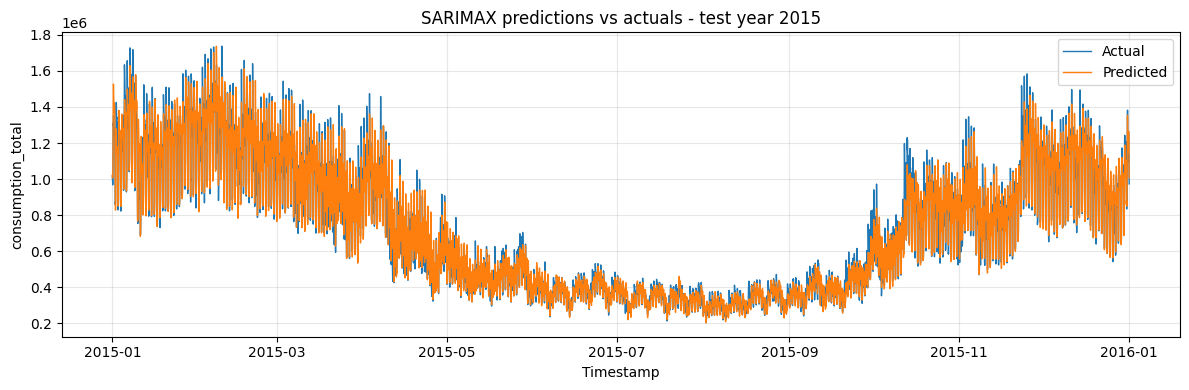

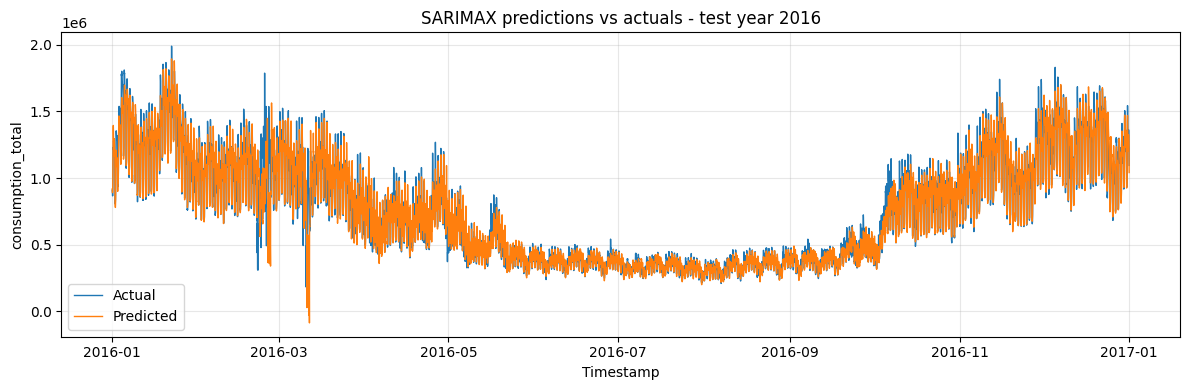

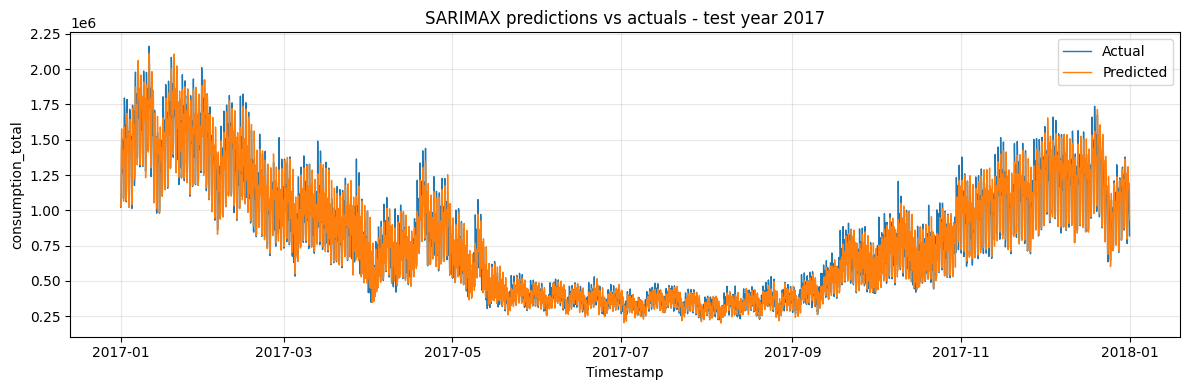

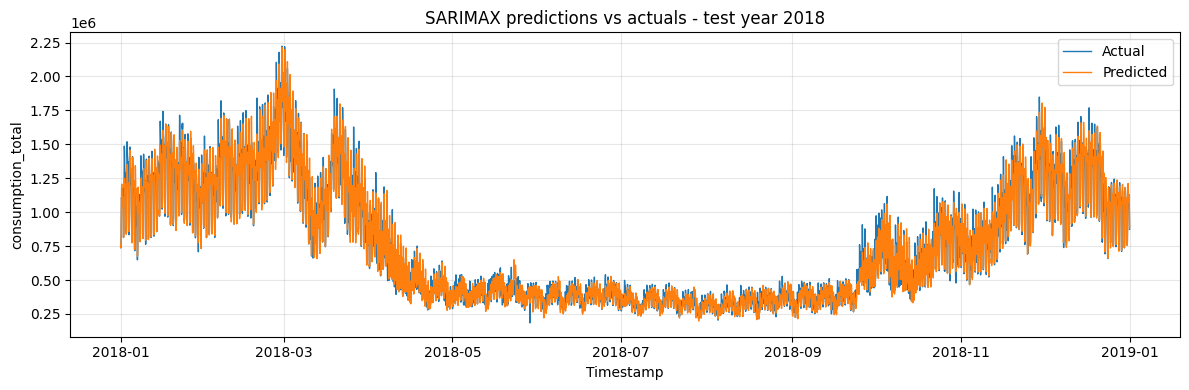

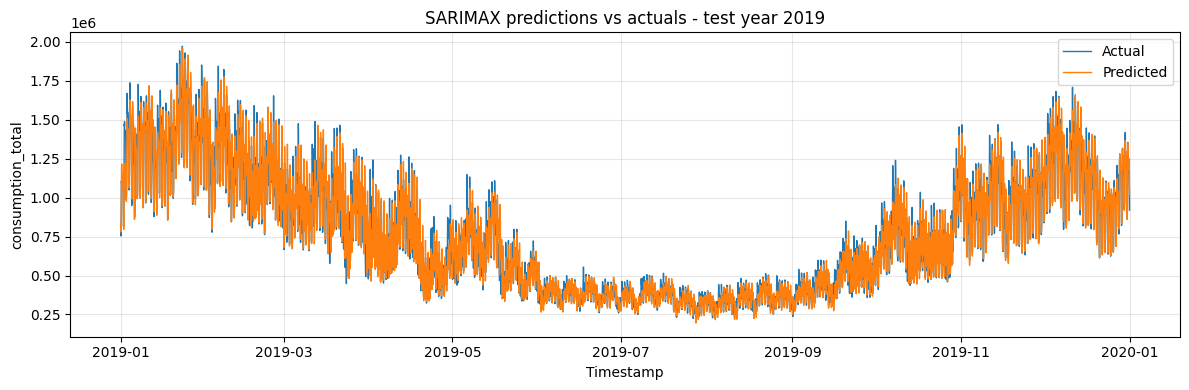

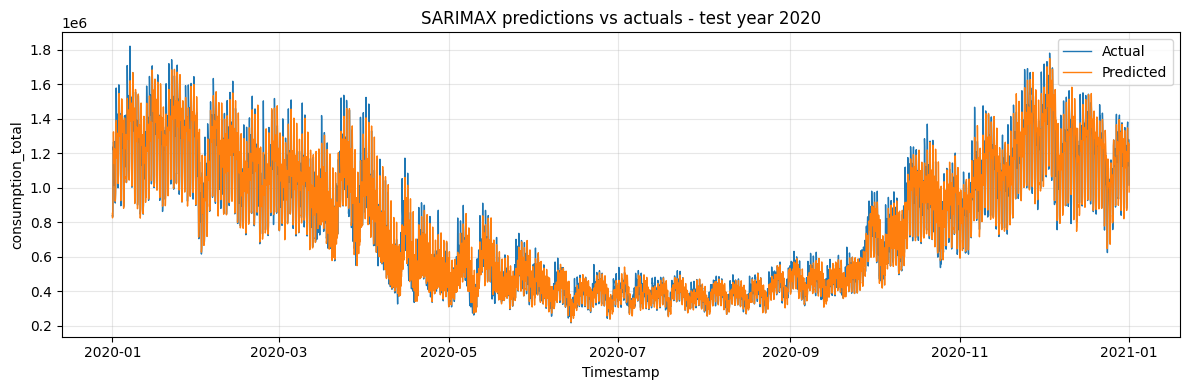

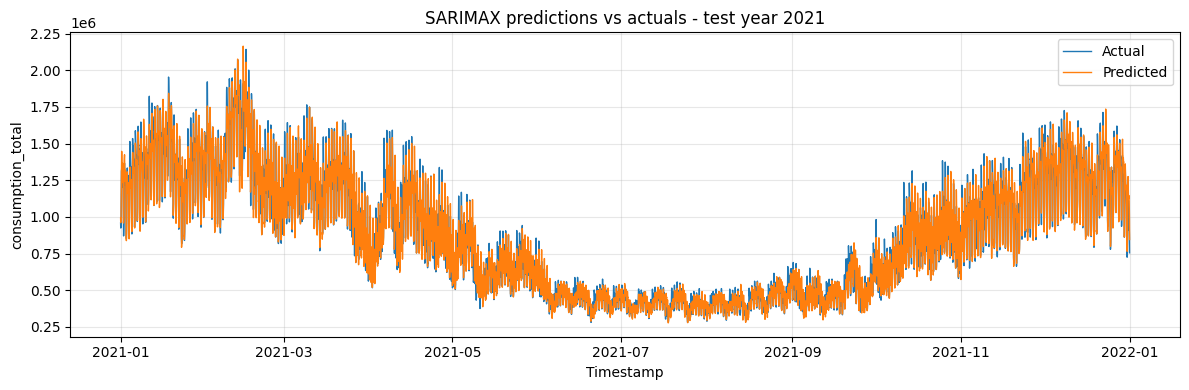

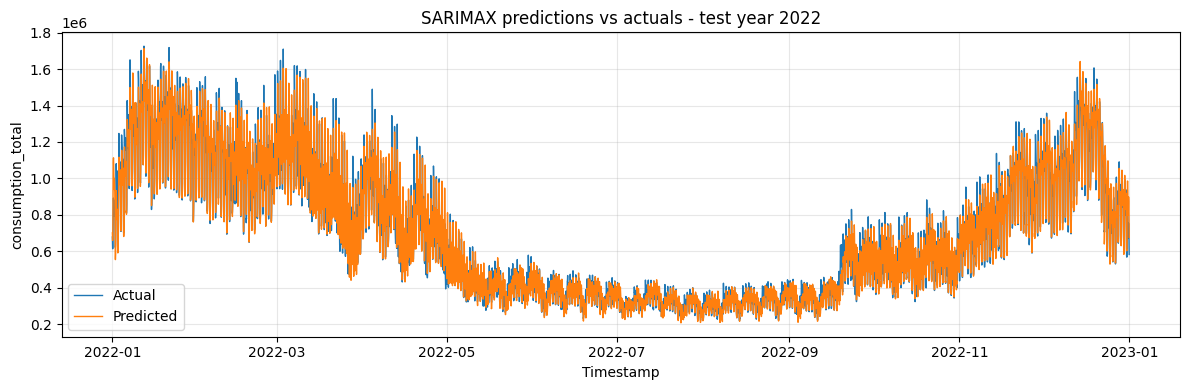

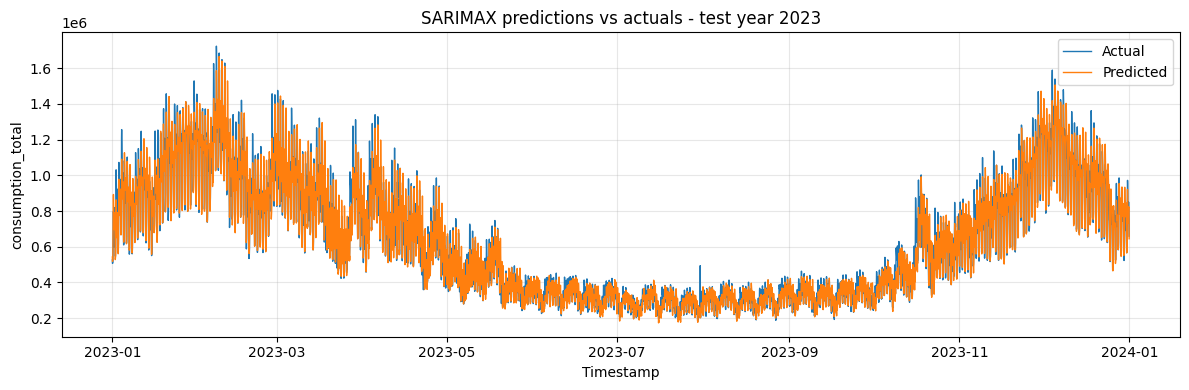

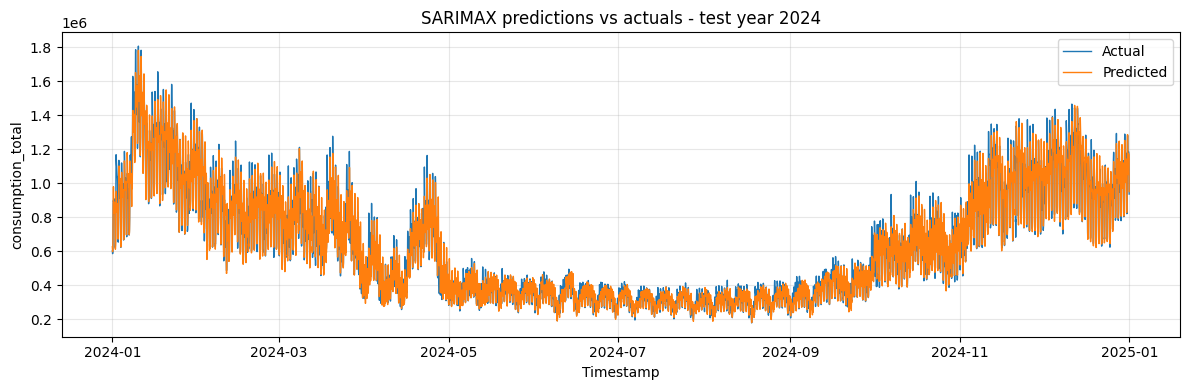

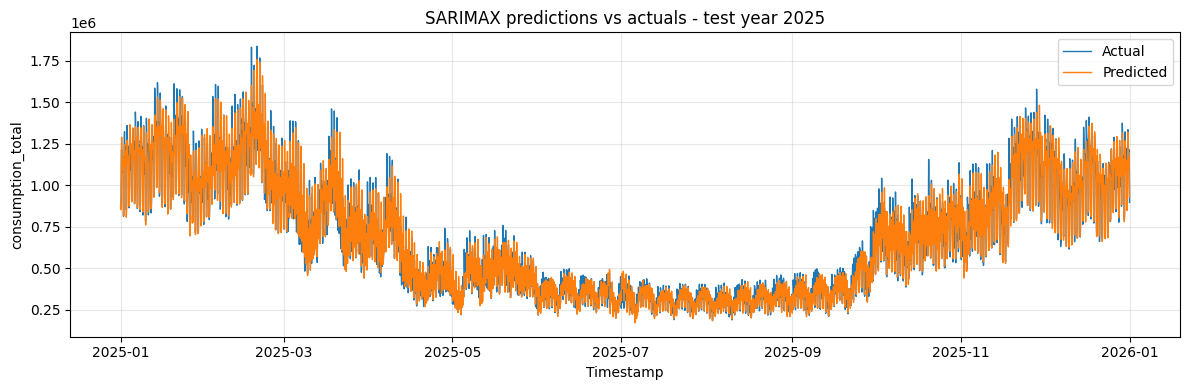

In [16]:
# Cross-fold metric trends
fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
metric_names = ["mae", "rmse", "mape", "smape", "r2"]

for ax, metric in zip(axes.flatten(), metric_names):
    ax.plot(metrics_df["test_year"], metrics_df[metric], marker="o")
    ax.set_title(metric.upper())
    ax.grid(alpha=0.3)

axes[-1, -1].axis("off")
axes[-1, 0].set_xlabel("Test year")
plt.tight_layout()
plt.show()

# Per-fold prediction plots
for row in metrics_df.itertuples(index=False):
    test_year = int(row.test_year)
    fold_pred = predictions_df[predictions_df["test_year"] == test_year].copy()
    fold_pred["timestamp"] = pd.to_datetime(fold_pred["timestamp"])

    plt.figure(figsize=(12, 4))
    plt.plot(fold_pred["timestamp"], fold_pred["y_true"], label="Actual", linewidth=1.0)
    plt.plot(
        fold_pred["timestamp"], fold_pred["y_pred"], label="Predicted", linewidth=1.0
    )
    plt.title(f"SARIMAX predictions vs actuals - test year {test_year}")
    plt.xlabel("Timestamp")
    plt.ylabel(CONFIG.target_col)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [17]:
expected_years = list(range(2014, 2026))
found_years = metrics_df["test_year"].tolist()

assert (
    found_years == expected_years
), f"Expected test years {expected_years}, got {found_years}"
assert len(metrics_df) == 12, f"Expected 12 fold metrics rows, got {len(metrics_df)}"
assert (metrics_df["n_predictions"] > 0).all(), "Some folds produced zero predictions"

saved_pred_files = sorted(PREDICTIONS_DIR.glob("sarimax_predictions_*.csv"))
assert (
    len(saved_pred_files) == 12
), f"Expected 12 per-year prediction files, got {len(saved_pred_files)}"
assert metrics_path.exists(), "Missing fold metrics CSV"
assert predictions_path.exists(), "Missing all-fold predictions CSV"

print("All sanity checks passed.")
print(f"Per-year prediction files: {len(saved_pred_files)}")
print(f"Metrics summary path: {metrics_path}")
print(f"All predictions path: {predictions_path}")

All sanity checks passed.
Per-year prediction files: 12
Metrics summary path: /local_storage/users/sli0124/diplomovy-projekt/results/sarimax/sarimax_fold_metrics.csv
All predictions path: /local_storage/users/sli0124/diplomovy-projekt/results/sarimax/sarimax_predictions_all_folds.csv


In [ ]:
# Quick smoke test on first fold only, to validate non-trivial metrics.
smoke_fold = folds[0]
smoke_test_year = int(smoke_fold["test_year"])
smoke_train_path = Path(smoke_fold["train_path"])
smoke_test_path = Path(smoke_fold["test_path"])

y_train_smoke, x_train_smoke = load_fold_frame(smoke_train_path, CONFIG.target_col)
y_test_smoke, x_test_smoke = load_fold_frame(smoke_test_path, CONFIG.target_col)

leaky_cols_smoke = [
    c for c in CONFIG.leaky_consumption_columns if c in x_train_smoke.columns
]
identity_residual = (
    float((y_train_smoke - x_train_smoke[leaky_cols_smoke].sum(axis=1)).abs().max())
    if leaky_cols_smoke
    else float("nan")
)
print(f"smoke fold test_year={smoke_test_year}")
print(f"max identity residual target-vs-components (train): {identity_residual:.6f}")

if CONFIG.exclude_leaky_consumption_exog and leaky_cols_smoke:
    x_train_smoke = x_train_smoke.drop(columns=leaky_cols_smoke)
    x_test_smoke = x_test_smoke.drop(columns=leaky_cols_smoke)
    print(f"dropped leakage columns in smoke run: {leaky_cols_smoke}")

x_train_smoke, x_test_smoke = scale_exog_by_train(x_train_smoke, x_test_smoke)
smoke_fit = fit_sarimax(y_train_smoke, x_train_smoke)
smoke_pred = rolling_forecast(
    fitted_model=smoke_fit,
    y_test=y_test_smoke,
    x_test=x_test_smoke,
    prediction_length=CONFIG.prediction_length,
    stride=CONFIG.stride,
)

smoke_metrics = compute_metrics(
    smoke_pred["y_true"].to_numpy(dtype=float),
    smoke_pred["y_pred"].to_numpy(dtype=float),
)
print("smoke metrics:", smoke_metrics)
print("first 5 preds:")
smoke_pred.head()

smoke fold test_year=2014
max identity residual target-vs-components (train): 0.000000
dropped leakage columns in smoke run: ['consumption_gasnet', 'consumption_jmpnet', 'consumption_smpnet', 'consumption_vcpnet']
smoke metrics: {'mae': 45217.525461442994, 'rmse': 81868.18977788668, 'mape': 6.577246422702457, 'smape': 6.4516875590288665, 'r2': 0.9429925948344883}
first 5 preds:


,timestamp,origin_timestamp,y_true,y_pred
0,2014-01-01 00:00:00,2014-01-01,752000.0,1.709851e+06
1,2014-01-01 01:00:00,2014-01-01,739884.0,1.677139e+06
2,2014-01-01 02:00:00,2014-01-01,736633.0,1.666986e+06
3,2014-01-01 03:00:00,2014-01-01,714643.0,1.683344e+06
4,2014-01-01 04:00:00,2014-01-01,718794.0,1.702160e+06
